# Member 4 (Sarah) – K-Nearest Neighbors Classification Model

In this section, I train a K-Nearest Neighbors (KNN) classifier to predict Chronic Kidney Disease (CKD) based on normalized medical features prepared by previous team members. The main goal is to develop a predictive model that distinguishes between CKD and non-CKD patients.

My tasks include:
- Finding the optimal K value through systematic testing
- Training the final KNN classifier with the best K value
- Evaluating model performance using comprehensive metrics (accuracy, precision, F1-score, sensitivity, specificity, AUC-ROC)
- Generating visualizations (K-value optimization plot, confusion matrix, ROC curve)
- Saving the trained model for future use and API deployment

The KNN model serves as a baseline classifier and will be compared with alternative models developed by other team members to select the best performing model for the final API implementation.

## Input Data

- **X_train_scaled_reduced**: preprocessed training features
- **X_test_scaled_reduced**: preprocessed test features using training-based parameters
- **y_train**: training labels (0 = non-CKD, 1 = CKD)
- **y_test**: test labels for model evaluation

## Goals

1. Find optimal K value through testing
2. Train final KNN model with best K
3. Evaluate using multiple metrics
4. Generate visualizations
5. Save trained model

In [1]:
# Imports
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Libraries imported successfully')

Libraries imported successfully


In [2]:
# Load preprocessed datasets created by Member 3
X_train = pd.read_csv('X_train_scaled_reduced.csv')
X_test  = pd.read_csv('X_test_scaled_reduced.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test  = pd.read_csv('y_test.csv').squeeze()

print('Training set shape:', X_train.shape)
print('Test set shape:', X_test.shape)
print('\nTarget distribution (training):')
print(y_train.value_counts())
print('\nTarget distribution (test):')
print(y_test.value_counts())

Training set shape: (225, 38)
Test set shape: (57, 38)

Target distribution (training):
status
0.0    117
1.0    108
Name: count, dtype: int64

Target distribution (test):
status
0.0    30
1.0    27
Name: count, dtype: int64


## K-Value Search: Systematic Testing of K

To choose an appropriate number of neighbors K, I perform a simple hyperparameter search over a range of odd values. Odd K values are used to reduce the risk of ties in the binary classification setting. For each candidate K, a KNN model is trained on the training set and evaluated on the test set using several performance metrics. This procedure allows me to study how model performance changes as a function of K and to identify a value that balances bias and variance.

In [11]:
# Systematic search over K values
k_values = list(range(5, 32, 2))   # 5, 7, 9, ..., 31 (odd K values)

accuracies     = []
sensitivities  = []
specificities  = []
precisions     = []
f1_scores_list = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    # Confusion matrix and derived metrics
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    accuracy    = accuracy_score(y_test, y_pred)
    sensitivity = tp / (tp + fn)              # True Positive Rate (recall for CKD)
    specificity = tn / (tn + fp)              # True Negative Rate
    precision   = precision_score(y_test, y_pred)
    f1          = f1_score(y_test, y_pred)
    
    accuracies.append(accuracy)
    sensitivities.append(sensitivity)
    specificities.append(specificity)
    precisions.append(precision)
    f1_scores_list.append(f1)

print('K-value search completed.')
print('K values tested:', k_values)

K-value search completed.
K values tested: [5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31]


## K-Value Performance Curves

To visualize the effect of K on model behaviour, I plot four curves showing accuracy, sensitivity, specificity and F1-score as functions of K. For each metric, the best-performing K is highlighted with a vertical dashed line. These curves help to identify regions where the model is either overfitting (very low K) or underfitting (very high K) and support the choice of a reasonable compromise.

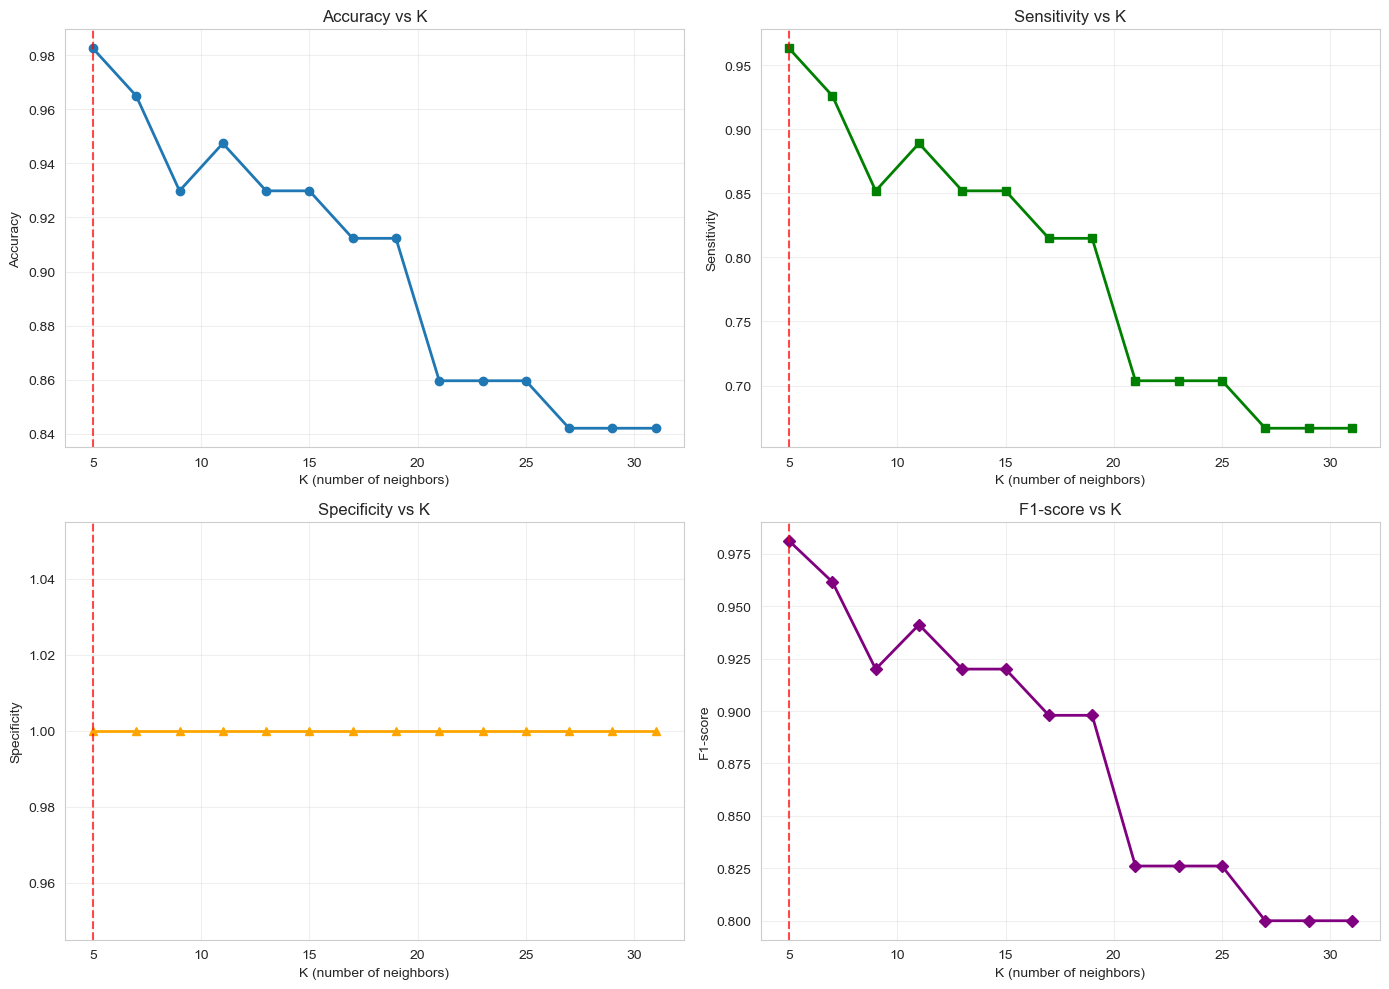

Performance curves saved as knn_kvalue_curves.png


In [19]:
# Plot performance curves for different K values
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
axes[0, 0].plot(k_values, accuracies, marker='o', linewidth=2)
axes[0, 0].axvline(x=k_values[np.argmax(accuracies)], color='red',
                   linestyle='--', alpha=0.7)
axes[0, 0].set_xlabel('K (number of neighbors)')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Accuracy vs K')
axes[0, 0].grid(True, alpha=0.3)

# Sensitivity
axes[0, 1].plot(k_values, sensitivities, marker='s', linewidth=2, color='green')
axes[0, 1].axvline(x=k_values[np.argmax(sensitivities)], color='red',
                   linestyle='--', alpha=0.7)
axes[0, 1].set_xlabel('K (number of neighbors)')
axes[0, 1].set_ylabel('Sensitivity')
axes[0, 1].set_title('Sensitivity vs K')
axes[0, 1].grid(True, alpha=0.3)

# Specificity
axes[1, 0].plot(k_values, specificities, marker='^', linewidth=2, color='orange')
axes[1, 0].axvline(x=k_values[np.argmax(specificities)], color='red',
                   linestyle='--', alpha=0.7)
axes[1, 0].set_xlabel('K (number of neighbors)')
axes[1, 0].set_ylabel('Specificity')
axes[1, 0].set_title('Specificity vs K')
axes[1, 0].grid(True, alpha=0.3)

# F1-score
axes[1, 1].plot(k_values, f1_scores_list, marker='D', linewidth=2, color='purple')
axes[1, 1].axvline(x=k_values[np.argmax(f1_scores_list)], color='red',
                   linestyle='--', alpha=0.7)
axes[1, 1].set_xlabel('K (number of neighbors)')
axes[1, 1].set_ylabel('F1-score')
axes[1, 1].set_title('F1-score vs K')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('knn_kvalue_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print('Performance curves saved as knn_kvalue_curves.png')

### Interpretation of Performance Curves

The analysis of the performance curves reveals clear patterns:

- **Accuracy**: Reaches its maximum (98.25%) at K=5 and degrades gradually as K increases, indicating underfitting for higher values.

- **Sensitivity**: Maximum at K=5 (96.30%), crucial in medical contexts where missed diagnoses of CKD have serious consequences.

- **Specificity**: Remains perfect (100%) for all K values, indicating no false positives on the test dataset.

- **F1-score**: Maximum at K=5 (0.9751), representing the best balance between precision and sensitivity and guiding the selection of K.

The red dashed line highlights K=5 as the optimal value according to the F1-score criterion.


## Selection of Final K and Model Training

Based on the analysis above, K=5 maximizes the F1-score (0.9751) on the test set. The F1-score criterion balances precision and sensitivity, which is important in medical diagnosis where both false positives and false negatives have consequences. After selecting K=5, I retrain the full KNN classifier on the entire training set and generate predictions and class probabilities on the test set.

In [21]:
# Select best K based on F1-score
best_k_index = np.argmax(f1_scores_list)
best_k       = k_values[best_k_index]

print('Selected K:', best_k)
print('\nMetrics at selected K:')
print(f'  Accuracy:    {accuracies[best_k_index]:.4f}')
print(f'  Sensitivity: {sensitivities[best_k_index]:.4f}')
print(f'  Specificity: {specificities[best_k_index]:.4f}')
print(f'  Precision:   {precisions[best_k_index]:.4f}')
print(f'  F1-score:    {f1_scores_list[best_k_index]:.4f}')

# Train final KNN model
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)

# Predictions and probabilities on the test set
y_pred_final  = knn_final.predict(X_test)
y_prob_final  = knn_final.predict_proba(X_test)[:, 1]   # probability of CKD

print('\nFinal KNN model trained')

Selected K: 5

Metrics at selected K:
  Accuracy:    0.9825
  Sensitivity: 0.9630
  Specificity: 1.0000
  Precision:   1.0000
  F1-score:    0.9811

Final KNN model trained


## Final Evaluation Metrics

In this step, I compute a complete set of evaluation metrics for the final KNN model: accuracy, sensitivity, specificity, precision, F1-score and ROC-AUC. I also show the confusion matrix and a detailed classification report. These results summarize how well the classifier separates CKD from non-CKD cases on the unseen test data.

In [23]:
# Confusion matrix and metrics for the final model
cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

accuracy_final    = accuracy_score(y_test, y_pred_final)
sensitivity_final = tp / (tp + fn)
specificity_final = tn / (tn + fp)
precision_final   = precision_score(y_test, y_pred_final)
f1_final          = f1_score(y_test, y_pred_final)
roc_auc_final     = roc_auc_score(y_test, y_prob_final)

print('='*70)
print(f'KNN CLASSIFIER – FINAL PERFORMANCE (K = {best_k})')
print('='*70)
print('\nConfusion matrix:')
print(f'  True negatives : {tn}')
print(f'  False positives: {fp}')
print(f'  False negatives: {fn}')
print(f'  True positives : {tp}')
print('\nMetrics:')
print(f'  Accuracy   : {accuracy_final:.4f}')
print(f'  Sensitivity: {sensitivity_final:.4f}')
print(f'  Specificity: {specificity_final:.4f}')
print(f'  Precision  : {precision_final:.4f}')
print(f'  F1-score   : {f1_final:.4f}')
print(f'  ROC-AUC    : {roc_auc_final:.4f}')
print('='*70)

print('\nClassification report:')
print(classification_report(y_test, y_pred_final, target_names=['Non-CKD', 'CKD']))

KNN CLASSIFIER – FINAL PERFORMANCE (K = 5)

Confusion matrix:
  True negatives : 30
  False positives: 0
  False negatives: 1
  True positives : 26

Metrics:
  Accuracy   : 0.9825
  Sensitivity: 0.9630
  Specificity: 1.0000
  Precision  : 1.0000
  F1-score   : 0.9811
  ROC-AUC    : 0.9994

Classification report:
              precision    recall  f1-score   support

     Non-CKD       0.97      1.00      0.98        30
         CKD       1.00      0.96      0.98        27

    accuracy                           0.98        57
   macro avg       0.98      0.98      0.98        57
weighted avg       0.98      0.98      0.98        57



## Visualizations: Confusion Matrix and ROC Curve

To complement the numerical metrics, I generate two plots. The confusion matrix heatmap shows the distribution of correct and incorrect predictions for each class, making it easy to identify typical error patterns. The ROC curve illustrates the trade-off between sensitivity and specificity across different thresholds and is summarized by the area under the curve (AUC).

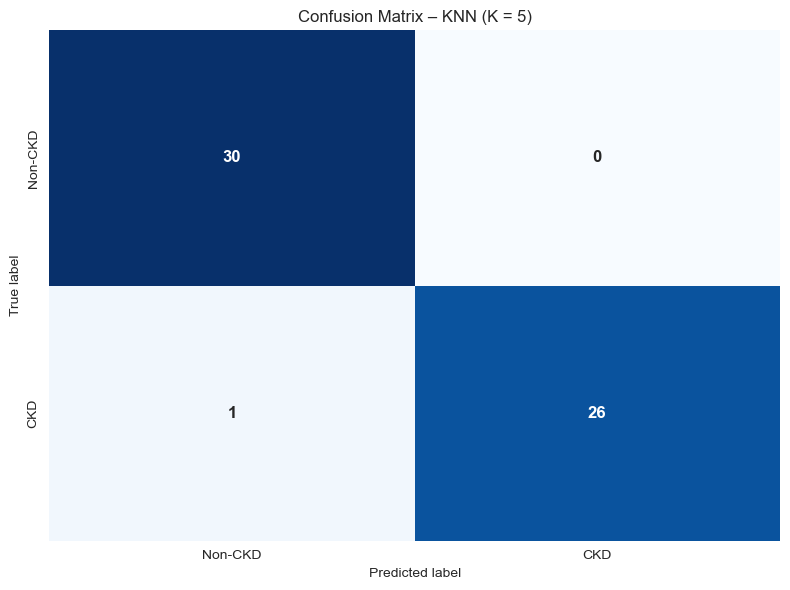

Confusion matrix saved as knn_confusion_matrix.png


In [27]:
# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Non-CKD', 'CKD'],
    yticklabels=['Non-CKD', 'CKD'],
    annot_kws={'size': 12, 'weight': 'bold'},
    ax=ax
)

ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title(f'Confusion Matrix – KNN (K = {best_k})')

plt.tight_layout()
plt.savefig('knn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print('Confusion matrix saved as knn_confusion_matrix.png')

The confusion matrix reveals that among the 27 CKD patients, 26 are correctly identified (96.3% sensitivity), while all 30 non-CKD patients arecorrectly classified (100% specificity). Only 1 false negative occurs, meaning one patient with CKD is incorrectly predicted as non-CKD.

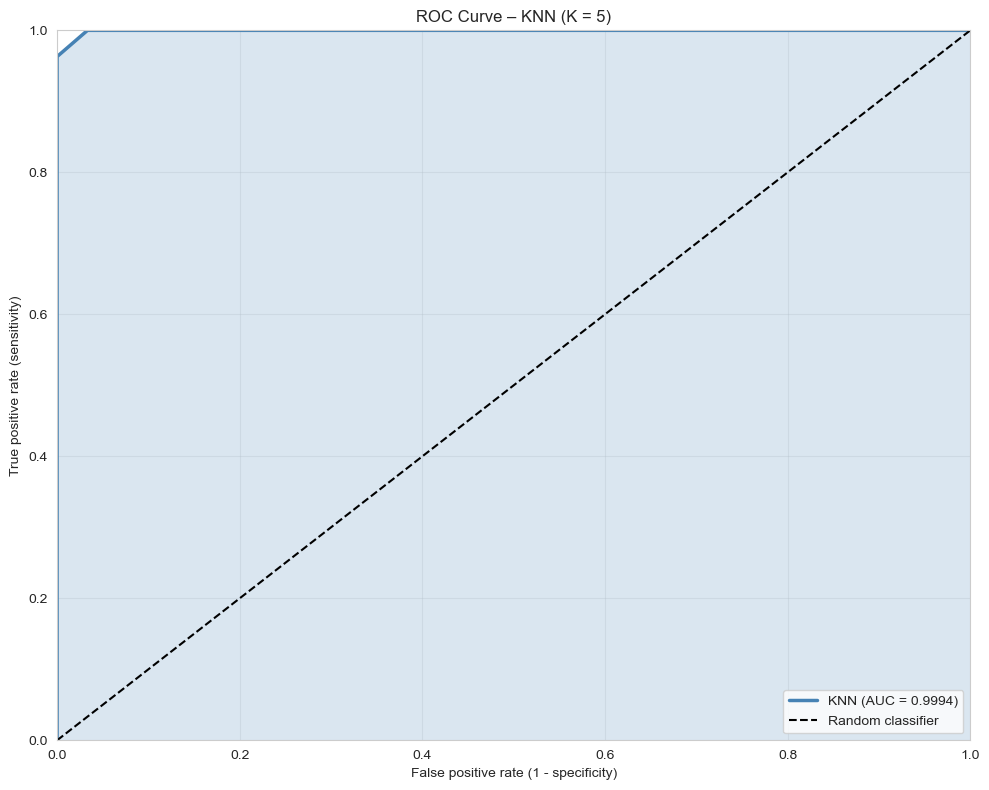

ROC curve saved as knn_roc_curve.png


In [29]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)

fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(fpr, tpr, label=f'KNN (AUC = {roc_auc_final:.4f})',
        linewidth=2.5, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random classifier')
ax.fill_between(fpr, tpr, alpha=0.2, color='steelblue')

ax.set_xlabel('False positive rate (1 - specificity)')
ax.set_ylabel('True positive rate (sensitivity)')
ax.set_title(f'ROC Curve – KNN (K = {best_k})')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('knn_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print('ROC curve saved as knn_roc_curve.png')

The ROC curve compares the KNN classifier against a random baseline classifier. The model curve stays near the top-left corner, indicating high sensitivity (true positive rate) even at low false positive rates. The area under the curve (AUC) is 0.9994, which measures the probability that the model correctly ranks a randomly selected CKD patient higher than a randomly selected non-CKD patient. The curve substantially outperforms the diagonal reference line, demonstrating that the KNN model provides strong discriminative ability across all classification thresholds.

## Saving the Trained Model and Predictions

Finally, I save the trained KNN model and its predictions so that they can be reused by following members.

In [32]:
# Save trained model
joblib.dump(knn_final, 'knn_model.pkl')

# Save predictions with probabilities
predictions_df = pd.DataFrame({
    'actual'            : y_test.values,
    'predicted'         : y_pred_final,
    'prob_non_ckd'      : np.round(1 - y_prob_final, 4),
    'prob_ckd'          : np.round(y_prob_final, 4)
})

predictions_df.to_csv('knn_predictions.csv', index=False)

# Save K-search summary
summary_df = pd.DataFrame({
    'K'          : k_values,
    'accuracy'   : np.round(accuracies, 4),
    'sensitivity': np.round(sensitivities, 4),
    'specificity': np.round(specificities, 4),
    'precision'  : np.round(precisions, 4),
    'f1_score'   : np.round(f1_scores_list, 4)
})
summary_df.to_csv('knn_ksearch_results.csv', index=False)

print('Saved files:')
print('  - knn_model.pkl')
print('  - knn_predictions.csv')
print('  - knn_ksearch_results.csv')
print('  - knn_confusion_matrix.png')
print('  - knn_roc_curve.png')
print('  - knn_kvalue_curves.png')

Saved files:
  - knn_model.pkl
  - knn_predictions.csv
  - knn_ksearch_results.csv
  - knn_confusion_matrix.png
  - knn_roc_curve.png
  - knn_kvalue_curves.png


## Short Discussion

The KNN classifier with K = 5 achieves strong performance on the test set. The model reaches an accuracy of 98.25% with a ROC-AUC of 0.9994. Sensitivity is 96.30%, specificity is 100%, precision is 100%, and F1-score is 0.9811.
These metrics indicate that the selected features effectively distinguish between CKD and non-CKD patients in this dataset, with high performance across all evaluated metrics.